In [1]:
import os, re
import numpy as np

# plotting styles
import matplotlib as mpl
from matplotlib import pyplot as plt

%matplotlib inline

mpl.rcParams['figure.dpi']= 150

In [2]:
import h5py

with h5py.File("../data/dr12q/processed/dla_samples_a03.mat", "r") as f:
    print(f.keys())
    # <KeysViewHDF5 ['alpha', 'fit_max_log_nhi', 'fit_min_log_nhi', 'log_nhi_samples', 'nhi_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>
    # log_nhi_samples.shape: (10000, 1)
    # alpha.shape: (1, 1)
    # offset_samples.shape: (10000, 1)
    # fit_min_log_nhi.shape: (1, 1)
    # fit_max_log_nhi.shape: (1, 1)
    # uniform_min_log_nhi.shape: (1, 1) 
    log_nhi_samples = f["log_nhi_samples"][:]
    alpha = f["alpha"][:]
    offset_samples = f["offset_samples"][:]
    fit_min_log_nhi = f["fit_min_log_nhi"][:]
    fit_max_log_nhi = f["fit_max_log_nhi"][:]
    uniform_min_log_nhi = f["uniform_min_log_nhi"][:]
    uniform_max_log_nhi = f["uniform_max_log_nhi"][:]
    nhi_samples = f["nhi_samples"][:]
    print("log_nhi_samples.shape:", log_nhi_samples.shape)
    print("alpha.shape:", alpha.shape)
    print("offset_samples.shape:", offset_samples.shape)
    print("fit_min_log_nhi.shape:", fit_min_log_nhi.shape)
    print("fit_max_log_nhi.shape:", fit_max_log_nhi.shape)
    print("uniform_min_log_nhi.shape:", uniform_min_log_nhi.shape)

<KeysViewHDF5 ['alpha', 'fit_max_log_nhi', 'fit_min_log_nhi', 'log_nhi_samples', 'nhi_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>
log_nhi_samples.shape: (10000, 1)
alpha.shape: (1, 1)
offset_samples.shape: (10000, 1)
fit_min_log_nhi.shape: (1, 1)
fit_max_log_nhi.shape: (1, 1)
uniform_min_log_nhi.shape: (1, 1)


Sum of the PDF:


1.0015712037656381

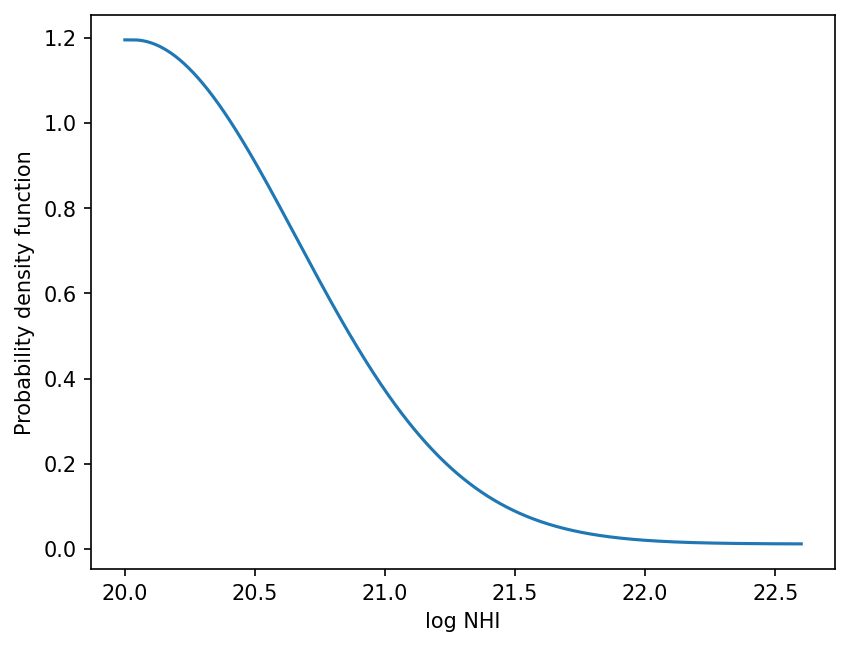

In [3]:
from scipy.integrate import quad # to get the normalization constant for the probability density function

# normalization factor a for uniform prior
a = 0.97
uniform_min_log_nhi = 20
uniform_max_log_nhi = 22.6

# directly use the fitted poly values in the Garnett (2017)
unnormalized_dla_pdf = lambda log_nhi: (np.exp(
    -1.2695 * log_nhi**2 + 50.863 * log_nhi -509.33
    )
)
# add a flat prior at the low column density end
unnormalized_pdf = lambda log_nhi : (
    unnormalized_dla_pdf(log_nhi) * (log_nhi >= 20.03) +
    unnormalized_dla_pdf(20.03)      * (log_nhi <  20.03)
)

Z = quad(unnormalized_pdf, uniform_min_log_nhi, uniform_max_log_nhi)[0]

# # % uniform component of column density prior
# u = makedist('uniform', ...
#              'lower', uniform_min_log_nhi, ...
#              'upper', uniform_max_log_nhi);
#           alpha  * (unnormalized_pdf(nhi) / Z) + ...
# #  (1 - alpha) * (pdf(u, nhi));
# % normalized PDF with uniform prior
normalized_pdf = lambda log_nhi: (
    a * unnormalized_pdf(log_nhi) / Z 
    + (1 - a) * (log_nhi >= uniform_min_log_nhi) * (log_nhi <= uniform_max_log_nhi) / (uniform_max_log_nhi - uniform_min_log_nhi)
)


log_nhis = np.linspace(uniform_min_log_nhi, uniform_max_log_nhi, num=1000)
plt.plot(log_nhis, normalized_pdf(log_nhis))
plt.xlabel("log NHI")
plt.ylabel("Probability density function")

# Make sure the probability density is summed to one
print("Sum of the PDF:")
np.sum(normalized_pdf(log_nhis) * (log_nhis[1] - log_nhis[0]))

In [4]:
xgrid = np.linspace(20, 22.6, 1000)
dx = xgrid[1] - xgrid[0]
integral = normalized_pdf(xgrid).sum() * dx
print(integral)  # should be very close to 1

1.0015712037656381


In [5]:
# We want Monte Carlo samples - here to use Halton sequence to speed up the convergence
from scipy.stats.qmc import Halton
from scipy.interpolate import interp1d

sampler = Halton(
    d=2, # dimension of parameter space
    scramble=True,
)



In [6]:
np.random.seed(42)  # for reproducibility

num_samples = 100000
halton_sequence = sampler.random(num_samples)

# Inver transform sampling
# https://en.wikipedia.org/wiki/Inverse_transform_sampling
# code ref:
# https://gist.github.com/amarvutha/c2a3ea9d42d238551c694480019a6ce1
def sample(g, min_lognhi = 20, max_lognhi = 22.6):
    x = np.linspace(
        min_lognhi,
        max_lognhi,
        num=int(1e8),               # if you see interpolation error, increase this number 
    )
    y = g(x)                        # probability density function, pdf
    cdf_y = np.cumsum(y)            # cumulative distribution function, cdf
    cdf_y = cdf_y/cdf_y.max()       # takes care of normalizing cdf to 1.0
    inverse_cdf = interp1d(cdf_y, x)    # this is a function
    return inverse_cdf

def return_samples(halton_sequence: np.ndarray):
    required_samples = sample(
        normalized_pdf
    )(halton_sequence)
    return required_samples

samples_log_nhis = return_samples(halton_sequence[:, 0], )

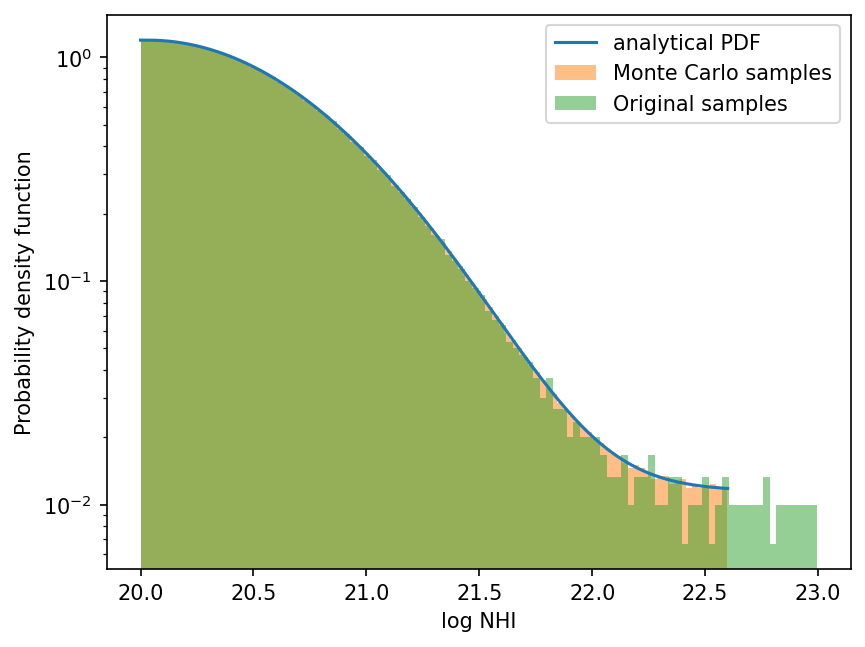

In [7]:
plt.plot(log_nhis, normalized_pdf(log_nhis), label="analytical PDF")
plt.xlabel("log NHI")
plt.ylabel("Probability density function")
plt.hist(samples_log_nhis, bins=100, density=True, alpha=0.5, label="Monte Carlo samples")
plt.hist(log_nhi_samples, bins=100, density=True, alpha=0.5, label="Original samples")

# yscale log
plt.yscale("log")
plt.legend()

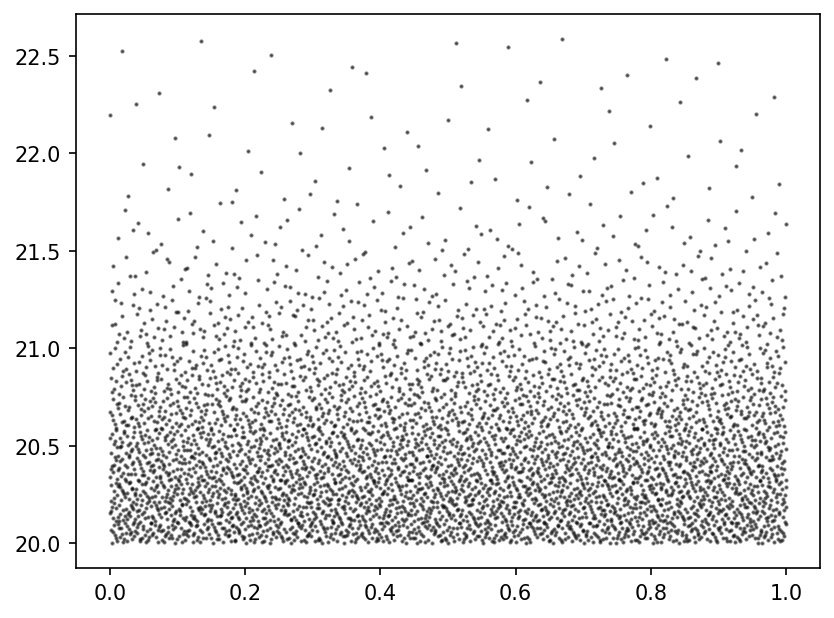

In [14]:
# visualize halton sequence
plt.scatter(
    halton_sequence[:5000, 1], samples_log_nhis[:5000], 
    s=1, alpha=0.5, c="black"
)
# # original
# plt.scatter(
#     offset_samples, log_nhi_samples, 
#     s=1, alpha=0.5, c="red"
# )

In [ ]:
def select_region_indices_searchsorted(initial_z, initial_logL, z_all, z_tol=0.02, logL_null=None):
    """    
    """
    if logL_null is None:
        logL_null = np.max(initial_logL)

    z_good = initial_z[initial_logL > logL_null]
    if len(z_good) == 0:
        return np.array([], dtype=int)  # no valid points

    z_good_sorted = np.sort(z_good)
    left = np.searchsorted(z_good_sorted, z_all - z_tol, side='left')
    right = np.searchsorted(z_good_sorted, z_all + z_tol, side='right')

    # Valid if at least one good z is within [z - z_tol, z + z_tol]
    mask = (right > left)
    return mask

In [35]:
initial_z = np.repeat(np.array([2.4, 2.6, 3.0, 3.2]), 2)  # repeat each value once
initial_logL = np.repeat(np.array([-200, -190, -220, -180]), 2)
z_all = halton_sequence[:, 1] * 1.5 + 2.0  # scale to a range similar to initial_z

inds = select_region_indices_searchsorted(initial_z, initial_logL, z_all, z_tol=0.01, logL_null=-195)
inds.sum()

2666

In [27]:
%%timeit
inds = select_region_indices_searchsorted(initial_z, initial_logL, z_all, z_tol=0.01, logL_null=-195)

2.76 ms ± 15.4 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


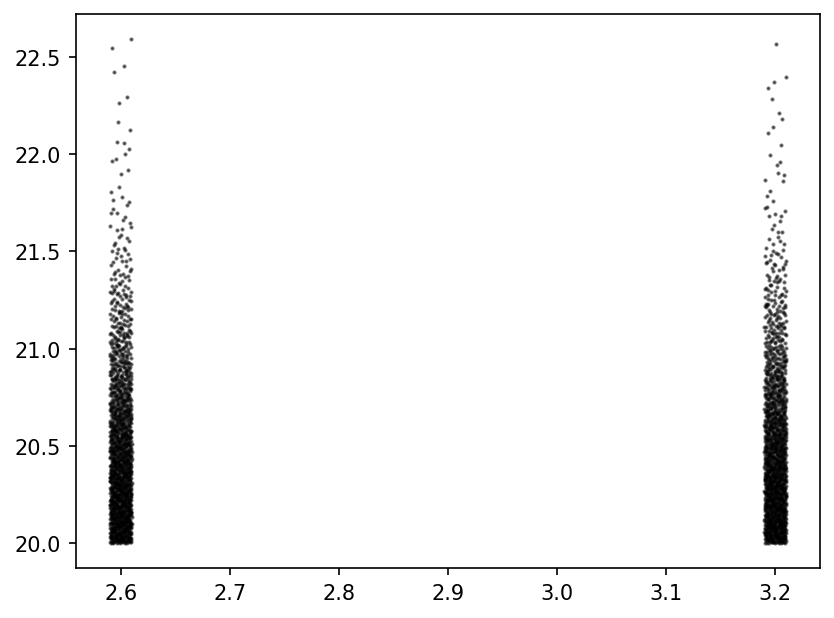

In [28]:
# visualize halton sequence
plt.scatter(
    z_all[inds], samples_log_nhis[inds], 
    s=1, alpha=0.5, c="black"
)
# # original
# plt.scatter(
#     offset_samples, log_nhi_samples, 
#     s=1, alpha=0.5, c="red"
# )

Save the samples

In [9]:
import h5py

with h5py.File("../data/dr12q/processed/dla_samples_a03_100000.mat", "w") as f:
    print(f.keys())
    # <KeysViewHDF5 ['alpha', 'fit_max_log_nhi', 'fit_min_log_nhi', 'log_nhi_samples', 'nhi_samples', 'offset_samples', 'uniform_max_log_nhi', 'uniform_min_log_nhi']>
    # log_nhi_samples.shape: (10000, 1)
    # alpha.shape: (1, 1)
    # offset_samples.shape: (10000, 1)
    # fit_min_log_nhi.shape: (1, 1)
    # fit_max_log_nhi.shape: (1, 1)
    # uniform_min_log_nhi.shape: (1, 1) 
    f.create_dataset("log_nhi_samples", data=samples_log_nhis[:, None])
    f.create_dataset("alpha", data=np.array([a])[:, None])
    f.create_dataset("offset_samples", data=halton_sequence[:, 1][:, None])
    f.create_dataset("fit_min_log_nhi", data=fit_min_log_nhi)
    f.create_dataset("fit_max_log_nhi", data=fit_max_log_nhi)
    f.create_dataset("uniform_min_log_nhi", data=np.array([uniform_min_log_nhi])[:, None])
    f.create_dataset("uniform_max_log_nhi", data=np.array([uniform_max_log_nhi])[:, None])
    f.create_dataset("nhi_samples", data=10**samples_log_nhis[:, None])
    print("Saved samples to ../data/dr12q/processed/dla_samples_a03_100000.mat")

# double check the shape of the samples
with h5py.File("../data/dr12q/processed/dla_samples_a03_100000.mat", "r") as f:
    log_nhi_samples = f["log_nhi_samples"][:]
    print("log_nhi_samples.shape:", log_nhi_samples.shape)
    assert log_nhi_samples.shape == (100000, 1)
    print("Samples shape is correct.")

    # other variables
    print("alpha.shape:", f["alpha"][:].shape)
    print("offset_samples.shape:", f["offset_samples"][:].shape)
    print("fit_min_log_nhi.shape:", f["fit_min_log_nhi"][:].shape)
    print("fit_max_log_nhi.shape:", f["fit_max_log_nhi"][:].shape)
    print("uniform_min_log_nhi.shape:", f["uniform_min_log_nhi"][:].shape)
    print("uniform_max_log_nhi.shape:", f["uniform_max_log_nhi"][:].shape)
    print("nhi_samples.shape:", f["nhi_samples"][:].shape)
    assert f["nhi_samples"][:].shape == (100000, 1)
    print("All shapes are correct.")


<KeysViewHDF5 []>
Saved samples to ../data/dr12q/processed/dla_samples_a03_100000.mat
log_nhi_samples.shape: (100000, 1)
Samples shape is correct.
alpha.shape: (1, 1)
offset_samples.shape: (100000, 1)
fit_min_log_nhi.shape: (1, 1)
fit_max_log_nhi.shape: (1, 1)
uniform_min_log_nhi.shape: (1, 1)
uniform_max_log_nhi.shape: (1, 1)
nhi_samples.shape: (100000, 1)
All shapes are correct.


## model prior

In [9]:
import sys, os

## Include previous level directories to the module import path
sys.path.insert(0, os.path.abspath(os.path.join("..")))


In [10]:
from gpy_dla_detection.set_parameters import Parameters

# Note: these parameters are used during training. Change these parameters here won't change your
# trained GP model unless you re-train your GP model.
param = Parameters(
    loading_min_lambda = 800,                     # range of rest wavelengths to load  Å
    loading_max_lambda = 1550,
    # normalization parameters
    normalization_min_lambda = 1425,              # range of rest wavelengths to use   Å
    normalization_max_lambda = 1475,              #   for flux normalization
    # null model parameters
    min_lambda         =  850.75,                 # range of rest wavelengths to       Å
    max_lambda         = 1420.75,                 #   model
    dlambda            =    0.25,                 # separation of wavelength grid      Å
    k                  = 20,                      # rank of non-diagonal contribution
    max_noise_variance = 3**2,                    # maximum pixel noise allowed during model training
)

# BOSS DR12 effective optical depth
param.tau_0_mu                  = 0.00554          # meanflux suppression for τ₀
param.tau_0_sigma               = 0.00064          # meanflux suppression for τ₀
param.beta_mu                   =   3.182          # meanflux suppression for β
param.beta_sigma                =   0.074          # meanflux suppression for β

param


{'loading_min_lambda': 800, 'loading_max_lambda': 1550, 'z_qso_cut': 2.15, 'min_num_pixels': 200, 'normalization_min_lambda': 1425, 'normalization_max_lambda': 1475, 'min_lambda': 850.75, 'max_lambda': 1420.75, 'dlambda': 0.25, 'k': 20, 'max_noise_variance': 9, 'initial_c_0': 0.1, 'initial_tau_0': 0.0023, 'initial_beta': 3.65, 'minFunc_options': {'MaxIter': 2000, 'MaxFunEvals': 4000}, 'num_dla_samples': 10000, 'alpha': 0.97, 'uniform_min_log_nhi': 20.0, 'uniform_max_log_nhi': 23.0, 'fit_min_log_nhi': 20.0, 'fit_max_log_nhi': 22.0, 'prior_z_qso_increase': 0.10006922855944561, 'width': 3, 'pixel_spacing': 0.0001, 'num_lines': 3, 'max_z_cut': 0.010006922855944561, 'min_z_cut': 0.010006922855944561, 'num_forest_lines': 31, 'tau_0_mu': 0.00554, 'tau_0_sigma': 0.00064, 'beta_mu': 3.182, 'beta_sigma': 0.074}

In [12]:
from gpy_dla_detection.model_priors import PriorCatalog

# Note: you need to follow the README to download these files! 
prior = PriorCatalog(
    param,
    "../data/dr12q/processed/catalog.mat",
    "../data/dla_catalogs/dr9q_concordance/processed/los_catalog",
    "../data/dla_catalogs/dr9q_concordance/processed/dla_catalog",
)


Text(0, 0.5, 'p(DLA | zQSO)')

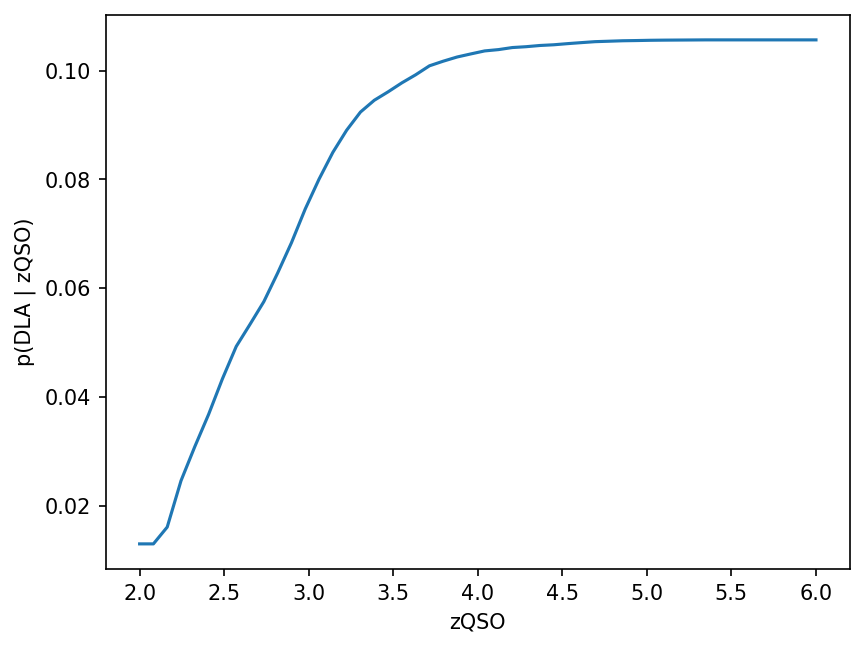

In [13]:
z_qso_list = np.linspace(2, 6)

dla_prior = []
for _z in z_qso_list:
    this_num_dlas, this_num_quasars = prior.less_ind(_z)

    # The prior of DLA = number of DLAs at a given redshift / (number of quasar sightlines with and without DLAs)
    _dla_prior = this_num_dlas / this_num_quasars
    dla_prior.append(_dla_prior)

plt.plot(z_qso_list, dla_prior, label="p(DLA | zQSO)")
plt.xlabel("zQSO")

plt.ylabel("p(DLA | zQSO)")
